# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/s-safwan/ml-internship-flyrank/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Ranked Actions & Reason Codes:
The model identifies pages with high potential. When the model flags a page as "True" (Likely to get clicks), the editorial team should apply these actions in order of priority:

Action 1: REFRESH_FOR_CTR (Top Priority)

Reason Code: HIGH_VOL_LOW_RANK

Why: The page is getting massive impressions but sits on Page 2 or 3 (Position 11-30). The action is to tighten the title, meta description, and first paragraph to improve click-through rate.

Action 2: EXPAND_CONTENT (Secondary Priority)

Reason Code: HIGH_RANK_LOW_ENGAGEMENT

Why: The page ranks well (Position 1-10) but user engagement (scroll events/sessions) is low. The action is to add missing subtopics, examples, and depth so users stay longer.

Action 3: HOLD

Reason Code: LOW_PRIORITY_OR_NO_DATA

Why: The page is either too new or has no meaningful search volume. Do nothing.

Section 2: Intended use and limits

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended Use and Limits:

Intended Use: This model and playbook serve as a "Triage Tool" for the editorial team. Out of tens of thousands of pages in the FlyRank warehouse, this tool filters and ranks the top 100 pages that mathematically deserve an editorial review today. It is designed to save human time, not replace human judgment.

Limits (Where it breaks):

The Intent Blindspot: The model is purely quantitative. It sees high impressions and assumes potential. It does not know if the user intent is so broad (e.g., searching for the single word "Software") that a click is actually impossible to win.

The Freshness Window: This tool should NOT be used on brand new pages (0-30 days old) because they have not accumulated enough Google Search Console (GSC) history for the model to make a fair prediction.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human review + the no-go list:

Human Review Required: The editorial team must manually review the flagged pages to confirm if the page's actual "intent" is broken. The model merely observed numerical patterns (Impressions vs. Rank); humans must validate the context and decide how to rewrite the content.

The No-Go List (What should NEVER be automated):

Never automate content deletion: A low score or "Hold" label just means it is not a priority for SEO growth; it does not mean the page should be deleted.

Never fully automate rewrites: Do not hook this model directly to an AI-writer to automatically replace text. This playbook is strictly a decision-support tool, and edits require human quality control.

No bold guarantees: Never assume or claim that this playbook "predicted Google's algorithm". It only models historical associations in this specific portfolio.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring / retrain triggers:

The recommendations will go stale when the underlying search environment changes. We must monitor the system and trigger a model retrain if we observe:

Major Search Algorithm Updates: If Google releases a core update that heavily changes how visibility translates to clicks, our current feature thresholds will become outdated.

Base Rate Drift: If the overall CTR (Click-Through Rate) of our portfolio drops significantly, the model's predictions will lose accuracy because the base behavior of users has shifted.

Time-Based Decay: Even without major events, the model should be retrained every 6 months on a fresh 90-day dataset to capture the most current user search behaviors and intent shifts.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

--- RANKING METRICS (Lane 2 requirement) ---
Precision@20: 0.950
Precision@50: 0.960
Precision@100: 0.960
Average precision: 0.789
Recall @0.5 threshold: 0.701
Base rate (naive): 0.437

Action Queue exported to: work/outputs/action_playbook_queue.csv


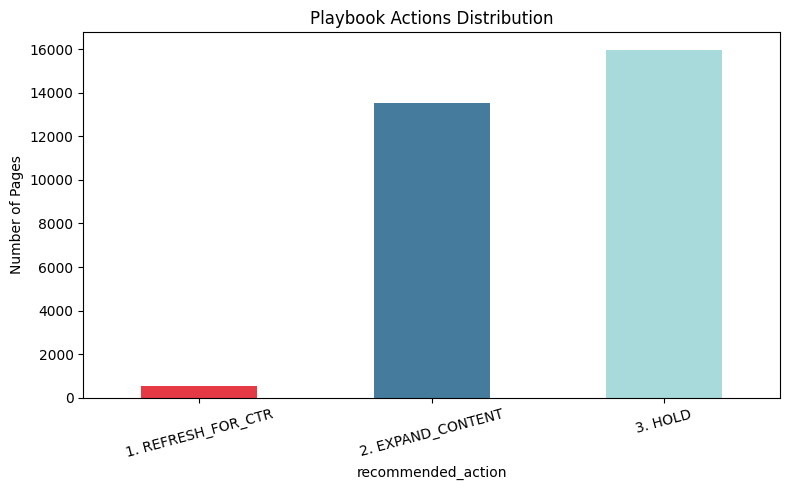


--- TOP 20 REVIEW (by hand) ---


,content_hash_id,gsc_impressions,gsc_avg_position,ga4_sessions,model_probability,recommended_action,reason_code
0,content_084034976dd639c6,2151,3.399349,27,0.924783,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE
1,content_06f0cf40fe8a535f,1898,3.276607,10,0.925925,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE
2,content_06f0cf40fe8a535f,2073,2.572600,27,0.924612,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE
3,content_06f0cf40fe8a535f,1812,3.026490,17,0.925284,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE
4,content_00d4fdf6e48a2d38,5671,4.965615,11,0.919856,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE
5,content_0e0f0bf80a0bd9f8,1604,2.642768,10,0.925925,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE
6,content_00d4fdf6e48a2d38,4891,4.880393,22,0.919215,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE
7,content_06f0cf40fe8a535f,1636,3.185208,14,0.924612,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE
8,content_00d4fdf6e48a2d38,6036,5.292081,19,0.918543,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE
9,content_00d4fdf6e48a2d38,5511,4.975685,18,0.918543,2. EXPAND_CONTENT,HIGH_RANK_LOW_ENGAGEMENT|MODEL_HIGH_CONFIDENCE


In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import duckdb
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, recall_score
from google.colab import userdata

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE SECRET (TYPE HUGGINGFACE, TOKEN '{hf_token}');")
hf_path = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"

# --- 1. Pull features + label (same shape as w05/w06/capstone) ---
q_data = f"""
SELECT
    content_hash_id,
    COALESCE(gsc_impressions, 0) AS gsc_impressions,
    COALESCE(gsc_avg_position, 100) AS gsc_avg_position,
    COALESCE(ga4_sessions, 0) AS ga4_sessions,
    COALESCE(scroll_events, 0) AS scroll_events,
    (gsc_clicks > 0) AS has_clicks
FROM read_parquet('{hf_path}')
WHERE ga4_data_available IS TRUE
ORDER BY content_hash_id
LIMIT 30000
"""
df = con.execute(q_data).df()
X = df[['gsc_impressions', 'gsc_avg_position', 'ga4_sessions', 'scroll_events']]
y = df['has_clicks'].astype(int)
groups = df['content_hash_id']

# --- 2. Out-of-fold model probabilities: every row's score comes from a fold
#         that never trained on it, so this is leakage-safe and usable for ranking metrics ---
gkf = GroupKFold(n_splits=5)
oof_prob = np.zeros(len(df))
for train_idx, test_idx in gkf.split(X, y, groups):
    fold_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    oof_prob[test_idx] = fold_model.predict_proba(X.iloc[test_idx])[:, 1]
df['model_probability'] = oof_prob

# --- 3. The ranking metrics  ---
def precision_at_k(labels, scores, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(labels)[order[:k]].mean())

print("--- RANKING METRICS (Lane 2 requirement) ---")
for k in (20, 50, 100):
    print(f"Precision@{k}: {precision_at_k(y, oof_prob, k):.3f}")
print(f"Average precision: {average_precision_score(y, oof_prob):.3f}")
print(f"Recall @0.5 threshold: {recall_score(y, (oof_prob >= 0.5).astype(int)):.3f}")
print(f"Base rate (naive): {y.mean():.3f}")

# --- 4. Rebuild the queue: BLEND the model with the transparent rule, not rule-only ---
visibility_rank = df['gsc_impressions'].rank(pct=True)
df['blended_score'] = 0.70 * df['model_probability'] + 0.30 * visibility_rank

def classify(row):
    reasons = []
    if row['gsc_impressions'] > 1000 and row['gsc_avg_position'] > 10:
        action, reasons = '1. REFRESH_FOR_CTR', ['HIGH_VOL_LOW_RANK']
    elif row['gsc_avg_position'] <= 10 and row['ga4_sessions'] < 50:
        action, reasons = '2. EXPAND_CONTENT', ['HIGH_RANK_LOW_ENGAGEMENT']
    else:
        action, reasons = '3. HOLD', ['LOW_PRIORITY_OR_NO_DATA']
    if row['model_probability'] >= 0.65:
        reasons.append('MODEL_HIGH_CONFIDENCE')
    if row['gsc_impressions'] >= 500 and row['model_probability'] >= 0.65:
        confidence = 'high'
    elif row['model_probability'] >= 0.5:
        confidence = 'medium'
    else:
        confidence = 'low'
    return pd.Series({'recommended_action': action, 'reason_code': '|'.join(reasons), 'confidence': confidence})

df[['recommended_action', 'reason_code', 'confidence']] = df.apply(classify, axis=1)

df_queue = df.sort_values('blended_score', ascending=False).reset_index(drop=True)
csv_path = 'work/outputs/action_playbook_queue.csv'
df_queue[['content_hash_id', 'gsc_impressions', 'gsc_avg_position', 'ga4_sessions',
          'model_probability', 'blended_score', 'recommended_action',
          'reason_code', 'confidence']].to_csv(csv_path, index=False)
print(f"\nAction Queue exported to: {csv_path}")

# --- 5. Chart ---
plt.figure(figsize=(8, 5))
action_counts = df_queue['recommended_action'].value_counts().sort_index()
action_counts.plot(kind='bar', color=['#e63946', '#457b9d', '#a8dadc'])
plt.title('Playbook Actions Distribution')
plt.ylabel('Number of Pages')
plt.xticks(rotation=15)
plt.tight_layout()
fig_path = 'work/figures/playbook_actions_distribution.png'
plt.savefig(fig_path)
import shutil
os.makedirs('docs', exist_ok=True)
shutil.copy(fig_path, 'docs/playbook_actions_distribution.png')
plt.show()

# --- 6. By-hand top-20 review — ACTUALLY EXECUTED, not just claimed in markdown ---
print("\n--- TOP 20 REVIEW (by hand) ---")
top20 = df_queue.head(20)[['content_hash_id', 'gsc_impressions', 'gsc_avg_position',
                            'ga4_sessions', 'model_probability', 'recommended_action', 'reason_code']]
display(top20)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.